 I built a Titanic Survival Prediction model using Logistic Regression in Python. 
 I handled missing values, encoded categorical variables like Sex and Embarked and 
 scaled features using StandardScaler. The model achieved 82.03% accuracy with 80.73% precision and 76.86% recall. 
 I used a confusion matrix to evaluate false positives and false negatives and 
 identified that Sex and Pclass were the strongest predictors of survival.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix, classification_report)
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Step 2 — Load the Dataset

In [2]:
df = pd.read_csv(r'E:\AIML THINGS\Projects\ml Projects 02\train.csv')

In [4]:
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.shape

(891, 12)

# Step 3 — Explore the Data (EDA)

In [ ]:
# Basic info
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


In [9]:
# Check missing values
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [10]:
# Check survival count
print("\nSurvival Count:")

print(df['Survived'].value_counts())


Survival Count:
Survived
0    549
1    342
Name: count, dtype: int64


🧹 Step 4 — Clean the Data

In [15]:
# Fill missing Age with median
df['Age'] = df['Age'].fillna(df['Age'].median())

# Fill missing Embarked with mode
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Drop Cabin (too many missing values)
df = df.drop(columns=['Cabin'])

#  Drop columns not useful for prediction
df = df.drop(columns=['Name', 'Ticket', 'PassengerId'])


In [16]:
df.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

🔄 Step 5 — Encode Categorical Columns

In [17]:
# Convert Sex: male=0, female=1
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])

# Convert Embarked: C=0, Q=1, S=2
df['Embarked'] = le.fit_transform(df['Embarked'])


In [18]:
df.head(3)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2


✂️ Step 6 — Split Features and Target

In [20]:
# Features and target
X = df[['Pclass'	,'Sex'	,'Age'	,'SibSp'	,'Parch'	,'Fare'	,'Embarked']]
y = df['Survived']


📏 Step 7 — Scale the Features

In [21]:
# Logistic Regression works better with scaled data

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)
print("Scaling Done!")

Scaling Done!


🔀 Step 8 — Train Test Split

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, 
    test_size=0.33, 
    random_state=42
)

🤖 Step 9 — Build & Train the Model

In [24]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


🔮 Step 10 — Make Predictions

In [25]:
y_pred = model.predict(X_test)

results = pd.DataFrame({
    'Actual' : y_test.values,
    'Predicated': y_pred
})

print(results.head(10))

   Actual  Predicated
0       1           0
1       0           0
2       0           0
3       1           1
4       1           1
5       1           1
6       1           1
7       0           0
8       1           1
9       1           1


📊 Step 11 — Evaluate the Model

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)


print("=" * 40)
print("     MODEL PERFORMANCE REPORT")
print("=" * 40)
print(f"Accuracy  : {accuracy  * 100:.2f}%")
print(f"Precision : {precision * 100:.2f}%")
print(f"Recall    : {recall    * 100:.2f}%")
print(f"F1 Score  : {f1        * 100:.2f}%")
print("=" * 40)

# Full report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))










     MODEL PERFORMANCE REPORT
Accuracy  : 82.03%
Precision : 80.73%
Recall    : 73.33%
F1 Score  : 76.86%

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.88      0.85       175
           1       0.81      0.73      0.77       120

    accuracy                           0.82       295
   macro avg       0.82      0.81      0.81       295
weighted avg       0.82      0.82      0.82       295



🟦 Step 12 — Confusion Matrix

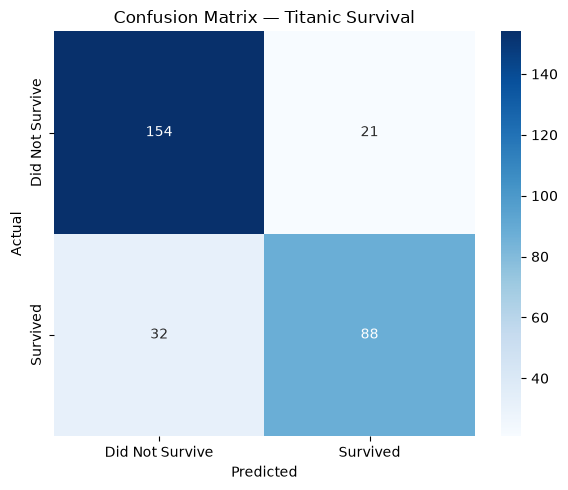


True Negatives  (Correctly predicted NOT survived): 154
False Positives (Wrongly predicted survived)      : 21
False Negatives (Missed actual survivors)         : 32
True Positives  (Correctly predicted survived)    : 88


In [27]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Did Not Survive', 'Survived'],
            yticklabels=['Did Not Survive', 'Survived'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Titanic Survival")
plt.tight_layout()
plt.show()

print(f"\nTrue Negatives  (Correctly predicted NOT survived): {cm[0][0]}")
print(f"False Positives (Wrongly predicted survived)      : {cm[0][1]}")
print(f"False Negatives (Missed actual survivors)         : {cm[1][0]}")
print(f"True Positives  (Correctly predicted survived)    : {cm[1][1]}")

🔮 Step 13 — Predict a New Passenger

In [28]:
# Predict survival for a new passenger
# Pclass, Sex, Age, SibSp, Parch, Fare, Embarked
new_passenger = pd.DataFrame({
    'Pclass'  : [3],      # 3rd class
    'Sex'     : [1],      # female (1)
    'Age'     : [25],     # 25 years old
    'SibSp'   : [0],      # no siblings
    'Parch'   : [0],      # no parents
    'Fare'    : [7.25],   # ticket fare
    'Embarked': [2]       # S = Southampton
})

new_scaled = scaler.transform(new_passenger)
prediction = model.predict(new_scaled)
probability = model.predict_proba(new_scaled)

print(f"Survived: {'Yes ✅' if prediction[0] == 1 else 'No ❌'}")
print(f"Survival Probability : {probability[0][1] * 100:.2f}%")
print(f"Death Probability    : {probability[0][0] * 100:.2f}%")

Survived: No ❌
Survival Probability : 11.41%
Death Probability    : 88.59%


In [31]:
import pickle
import os

# Check where notebook is saving files
print("Saving to:", os.getcwd())

# Save model
with open('titanic_model.pkl', 'wb') as f:
    pickle.dump(model, f)

# Save scaler
with open('titanic_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("✅ titanic_model.pkl saved!")
print("✅ titanic_scaler.pkl saved!")
print("Files in folder:", os.listdir())

Saving to: e:\AIML THINGS\Projects\ml Projects 02
✅ titanic_model.pkl saved!
✅ titanic_scaler.pkl saved!
Files in folder: ['requirements.txt', 'titanic-datasets.ipynb', 'titanic.py', 'titanic_model.pkl', 'titanic_scaler.pkl', 'train.csv']
